In [2]:
import psycopg2
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()
user=os.getenv('DB_USER')
password=os.getenv('DB_PASSWORD')
host=os.getenv('DB_HOST')
port=os.getenv('DB_PORT')
database=os.getenv('DB_NAME')

##use your own credentialas
engine=create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')
query="SELECT*FROM Zepto"
df=pd.read_sql(query,engine)

print(df.head())

     id             category              name    mrp  discountpercent  \
0   224  Fruits & Vegetables             Onion   25.0               16   
1   225  Fruits & Vegetables     Tomato Hybrid   42.0               16   
2   226  Fruits & Vegetables    Tender Coconut   51.0               15   
3  1577            Beverages  Amul Fresh Cream   63.0                0   
4  1914        Packaged Food       MTR Dal Fry  110.0                0   

   availablequantity  discountedsellingprice  weightingms  outofstock  \
0                  3                    21.0         1000       False   
1                  3                    35.0         1000       False   
2                  3                    43.0           58       False   
3                  0                    63.0          250        True   
4                  5                   110.0          300       False   

   quantity  
0         1  
1         1  
2         1  
3       250  
4       300  


In [4]:
print(df['outofstock'].unique())

[False  True]


In [5]:
print(df.shape)
print(df.dtypes)

(3731, 10)
id                          int64
category                   object
name                       object
mrp                       float64
discountpercent             int64
availablequantity           int64
discountedsellingprice    float64
weightingms                 int64
outofstock                   bool
quantity                    int64
dtype: object


In [6]:
print(df.isnull().sum())

id                        0
category                  0
name                      0
mrp                       0
discountpercent           0
availablequantity         0
discountedsellingprice    0
weightingms               0
outofstock                0
quantity                  0
dtype: int64


In [7]:
print(df.describe())

                id          mrp  discountpercent  availablequantity  \
count  3731.000000  3731.000000      3731.000000        3731.000000   
mean   2089.033503   156.843206         7.619137           4.009381   
std    1077.247361   160.889152         9.212123           2.203256   
min     224.000000    10.000000         0.000000           0.000000   
25%    1156.500000    60.000000         0.000000           2.000000   
50%    2089.000000   110.000000         6.000000           5.000000   
75%    3021.500000   200.000000        10.000000           6.000000   
max    3955.000000  2600.000000        51.000000           6.000000   

       discountedsellingprice   weightingms     quantity  
count             3731.000000   3731.000000  3731.000000  
mean               141.966390    387.927633   213.307960  
std                138.506329    678.168050   194.743915  
min                  9.000000      0.000000     0.000000  
25%                 55.000000    100.000000    50.000000  
50%   

In [8]:
count_per_category=df.groupby('category').size().reset_index(name='count')
print(count_per_category)


                 category  count
0               Beverages    129
1                Biscuits    147
2    Chocolates & Candies    388
3      Cooking Essentials    514
4   Dairy, Bread & Batter    129
5     Fruits & Vegetables     93
6        Health & Hygiene     97
7         Home & Cleaning    193
8    Ice Cream & Desserts    388
9      Meats, Fish & Eggs     63
10               Munchies    514
11            Paan Corner    344
12          Packaged Food    388
13          Personal Care    344


In [9]:
mean_mrp=df['mrp'].mean

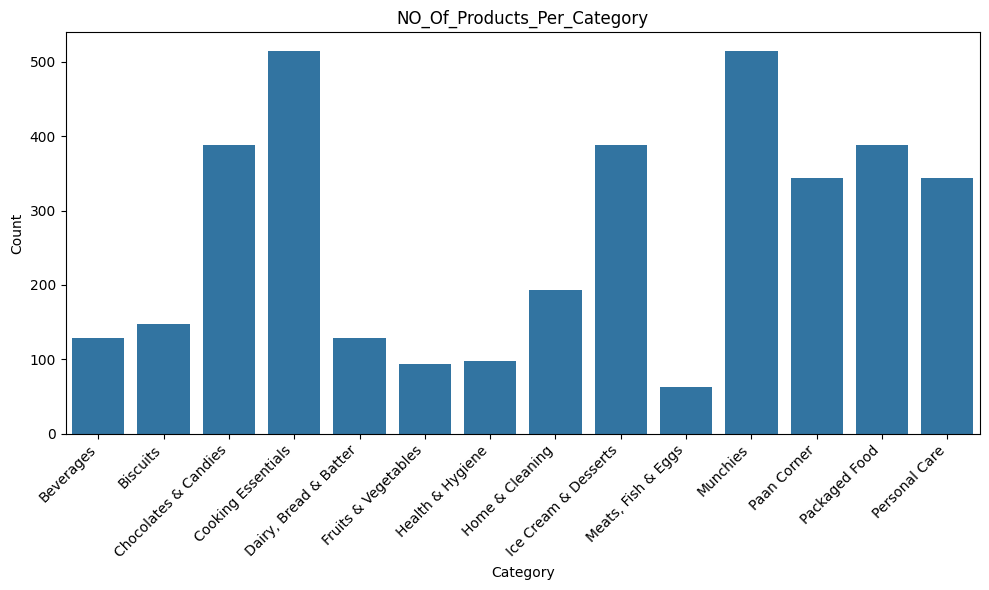

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(data=count_per_category,x='category',y='count')
plt.title('NO_Of_Products_Per_Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

## Observation — Products Per Category

- Cooking Essentials and Munchies dominate with 500+ SKUs
- Meat, Fish & Eggs has the least variety with under 100 SKUs
- Business Insight: Zepto should focus on expanding 
  low-variety categories to attract more customers

In [11]:
mrp_mean=df['mrp'].mean()
mrp_median=df['mrp'].median()

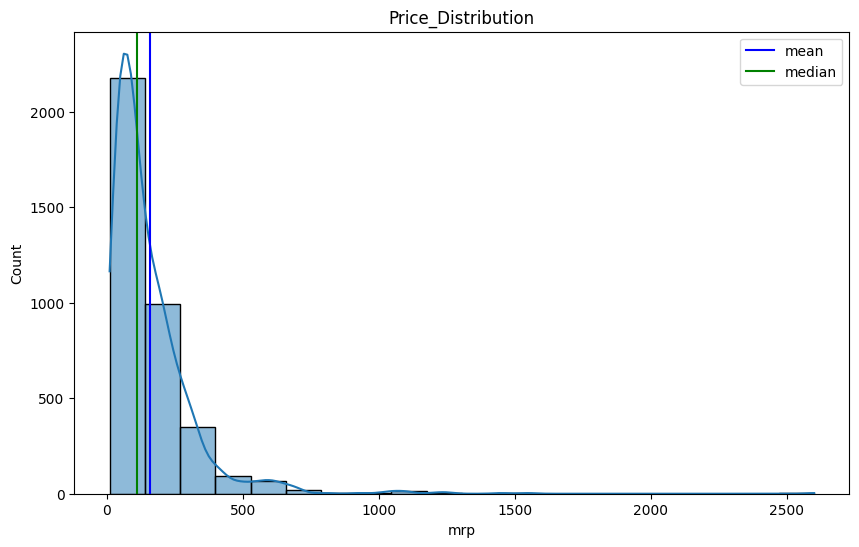

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['mrp'],bins=20,kde='True')
plt.title('Price_Distribution')
plt.axvline(mrp_mean,label='mean',c='blue')
plt.axvline(mrp_median,label='median',c='green')
plt.legend()
plt.show()


  Observation — Mrp Distribution

- Majority of Zepto products are priced under ₹200
- Mean is slightly higher than median confirming 
  right skewed distribution
- A small number of premium products go up to ₹2500
- Zepto's core market is budget conscious customers

In [13]:
discount_mean=df['discountpercent'].mean()
discount_median=df['discountpercent'].median()

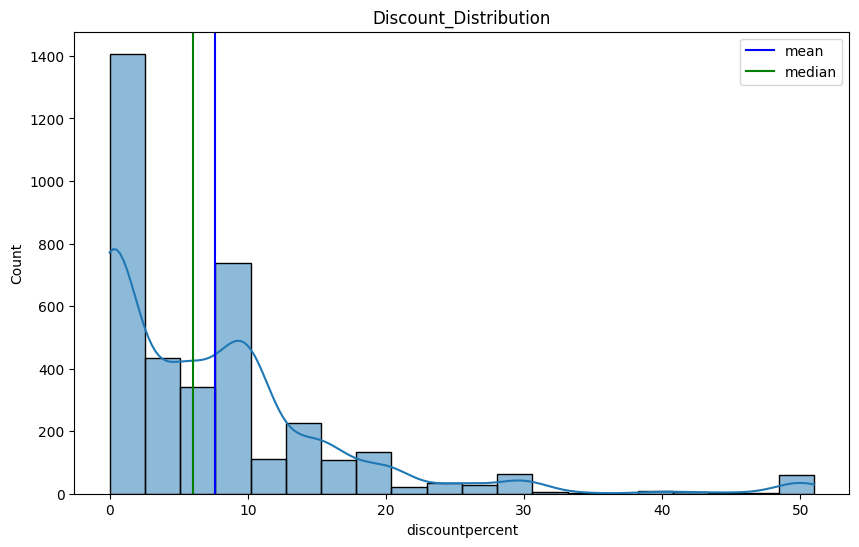

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['discountpercent'],bins=20,kde='True')
plt.title("Discount_Distribution")
plt.axvline(discount_mean,label='mean',c='blue')
plt.axvline(discount_median,label='median',c='green')
plt.legend()
plt.show()

   Observation — Discount Distribution

- Majority of Zepto products have zero or very low discounts
- Average discount is between 5-10%
- Heavy discounts above 30% are extremely rare
- Zepto is not a discount-heavy platform — 
  it competes more on availability and convenience

In [15]:
stock_status = df['outofstock'].value_counts()
print(stock_status)

outofstock
False    3278
True      453
Name: count, dtype: int64


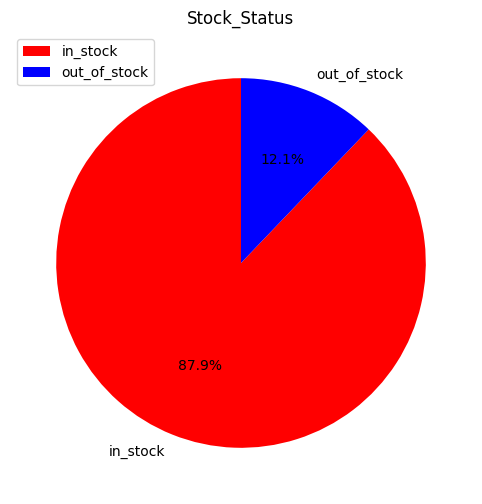

In [16]:
plot_labels=['in_stock','out_of_stock']
plot_colour=['red','Blue']
plt.figure(figsize=(10,6))
plt.pie(stock_status,labels=plot_labels,colors=plot_colour , startangle=90,autopct='%1.1f%%')
plt.title("Stock_Status")
plt.legend()
plt.show()

    Observation — stock status

- 87.9% of Zepto products are currently in stock
- 12.1% are out of stock — roughly 450 products unavailable
- For a quick commerce platform this is a 
  reasonable availability rate
- However out of stock premium products represent 
  direct revenue loss — identified in SQL analysis

In [17]:
discount_per_category = df.groupby('category')['discountpercent'].mean().reset_index()
print(discount_per_category)

                 category  discountpercent
0               Beverages         7.155039
1                Biscuits         8.244898
2    Chocolates & Candies         8.324742
3      Cooking Essentials         7.163424
4   Dairy, Bread & Batter         7.155039
5     Fruits & Vegetables        15.462366
6        Health & Hygiene         8.051546
7         Home & Cleaning         5.704663
8    Ice Cream & Desserts         8.324742
9      Meats, Fish & Eggs        11.031746
10               Munchies         7.163424
11            Paan Corner         6.250000
12          Packaged Food         8.324742
13          Personal Care         6.250000


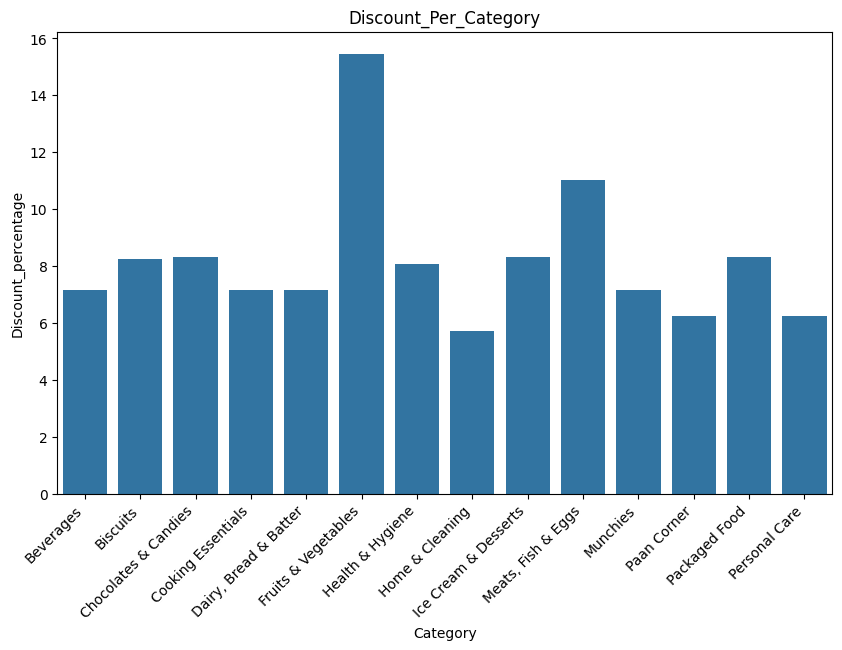

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=discount_per_category,x='category',y='discountpercent')
plt.title("Discount_Per_Category")
plt.xticks(rotation=45,ha='right')
plt.xlabel("Category")
plt.ylabel("Discount_percentage")
plt.show()

    Observation — Category Wise Discount

- Fruits & Vegetables leads with ~15% average discount
- Most categories offer only 6-9% average discount
- Home & Cleaning has the least promotional activity
- Perishable categories get higher discounts to 
  drive faster sales and reduce wastage

In [19]:
df['revenue']=df['discountedsellingprice']*df['availablequantity']
category_revenue=df.groupby('category')['revenue'].sum().reset_index()

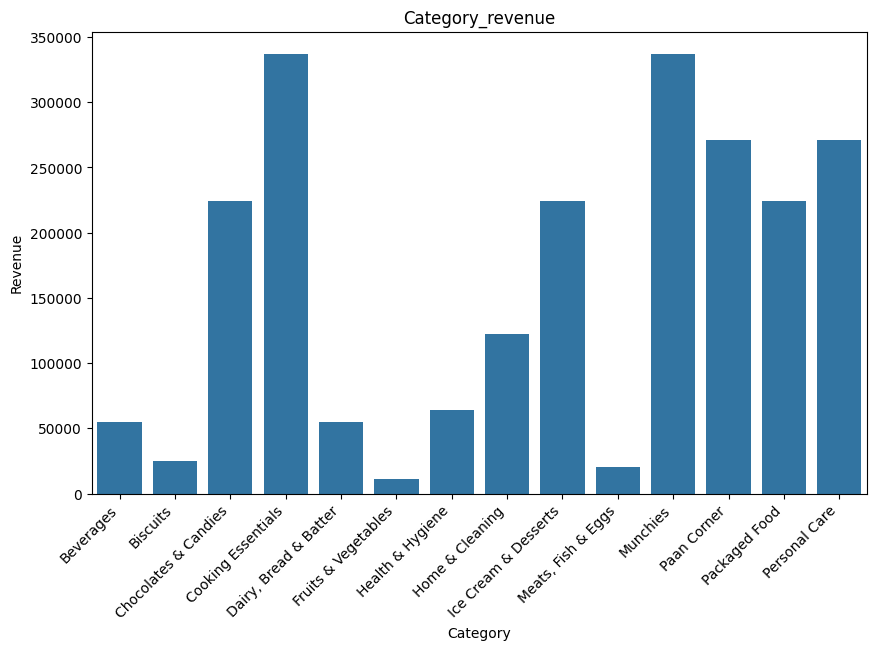

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_revenue,x='category',y='revenue')
plt.title("Category_revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45,ha='right')
plt.show()

   Observation — Revenue Of Each Category

- Cooking Essentials and Munchies are top 
  revenue contributors at ~₹335,000 each
- Biscuits and Fruits & Vegetables generate 
  the least revenue despite high product count
- High discount in Fruits & Vegetables is NOT 
  translating to revenue — needs business attention
- This disconnect between discount and revenue 
  is a key finding for marketing strategy

In [21]:
num_df = df.select_dtypes(include=['number'])
corr=num_df.corr()

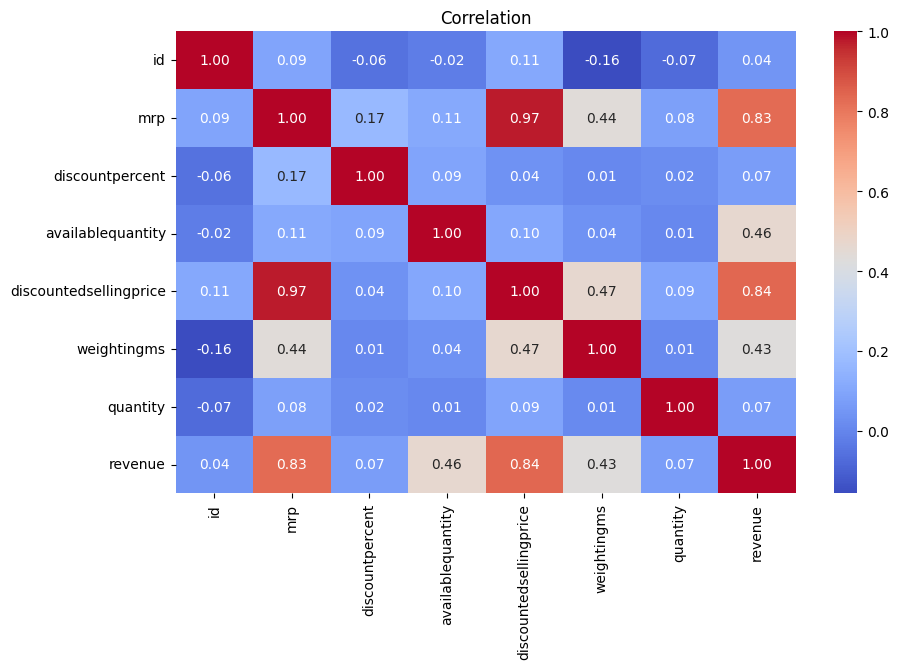

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(data=corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation")
plt.show()

     Observation — Correlation
- MRP and selling price are almost perfectly 
  correlated (0.97) as expected
- Revenue is driven by price (0.83) not discounts (0.07)
- Discounts show near zero correlation with all columns
- Zepto should focus on pricing strategy over 
  discounting to grow revenue

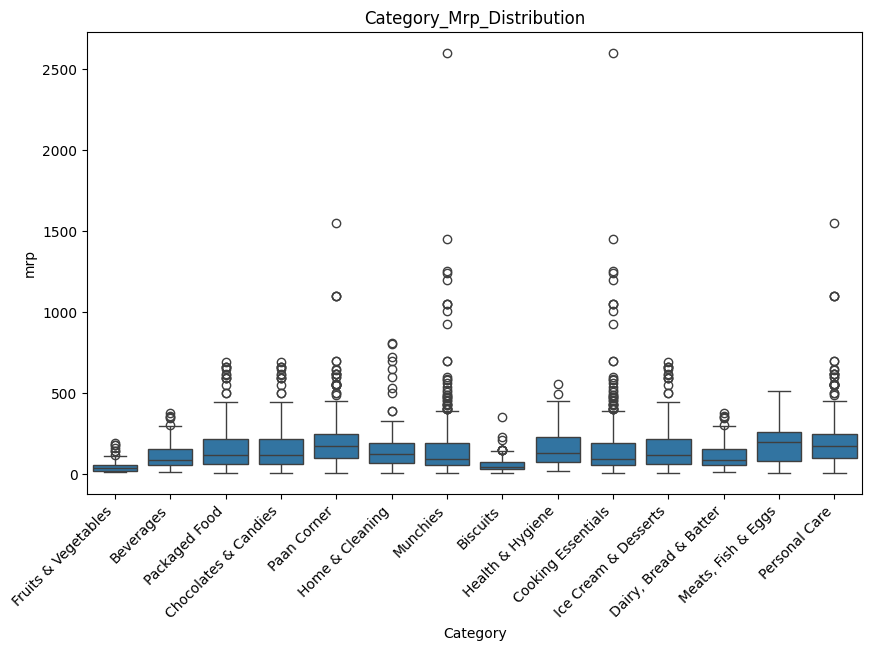

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='mrp')
plt.title("Category_Mrp_Distribution")
plt.xlabel('Category')
plt.ylabel("mrp")
plt.xticks(rotation=45,ha='right')
plt.show()

       Observation — category outliers
- Every category has premium outlier products
- Fruits & Vegetables has most consistent 
  pricing — all products similarly priced
- Personal Care has the widest price range
- Home & Cleaning has extreme outliers up to ₹2500
- Outliers represent premium SKUs that need 
  separate marketing strategy